# Advanced Build: Synthetic Data Generation with LangGraph Agent Graph

In this notebook, we'll implement synthetic data generation using LangGraph Agent Graph instead of the Knowledge Graph approach used in the main assignment. We'll use the Evol Instruct method to generate synthetic data.

## Objectives

Our goal is to create a system that will:
1. Take a list of LangChain Documents as input
2. Use LangGraph to orchestrate the evolution of questions through:
   - Simple Evolution
   - Multi-Context Evolution
   - Reasoning Evolution
3. Output:
   - List of evolved questions with IDs and evolution types
   - List of question IDs with their answers
   - List of question IDs with relevant contexts

Let's get started!

In [ ]:
# Import required libraries
import os
import getpass
from typing import Dict, List, Optional, Tuple
from uuid import uuid4

from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.prompts import ChatPromptTemplate
from langchain.schema import Document
from langgraph.graph import StateGraph, END, START
from pprint import pprint
import nest_asyncio
nest_asyncio.apply()

# Set up environment variables
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"Evolv-Instruct - {uuid4().hex[0:8]}"

In [2]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

In [3]:
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

## Step 1: Document Loading and Preprocessing

First, we'll load our loan-related PDF documents and preprocess them for our synthetic data generation pipeline. We'll:
1. Load the PDF documents from the data directory
2. Split them into manageable chunks
3. Create a preprocessing function to extract key information

In [95]:
# Load documents
path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
documents = loader.load()

# Split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separators=["\n\n", "\n", ".", "!", "?", ",", " ", ""],
    length_function=len,
)
split_docs = text_splitter.split_documents(documents)

# Create a preprocessing function to extract key information
def preprocess_document(doc: Document) -> Dict:
    """Extract key information from a document chunk."""
    return {
        "id": str(uuid4()),
        "content": doc.page_content,
        "metadata": doc.metadata,
        "key_points": [],  # Will be filled by the evolution process
        "relationships": [],  # Will track connections between documents
        "complexity_level": 1  # Will be used for evolution difficulty
    }

# Preprocess all documents
processed_docs = [preprocess_document(doc) for doc in split_docs][100:125]
print(f"Loaded and processed {len(processed_docs)} document chunks")

Loaded and processed 25 document chunks


## Step 2: Evolution Components Setup

We'll now implement the core components for our evolution-based question generation:
1. Set up the LLM for question generation
2. Create the base prompts for each evolution type
3. Implement the key point extraction function
4. Create the relationship identification function

In [113]:
# Set up LLM for generation
llm = ChatOpenAI(
    model="gpt-4.1-nano",
    temperature=0.7  # Slightly higher temperature for creative question generation
)

### Structured Output for LLM Calls

In [125]:
from pydantic import BaseModel, Field
from typing import List, Optional

class KeyPointsOutput(BaseModel):
    """Output format for extracting key points from a document"""
    key_points: List[str] = Field(description="Keypoints extracted from the document")

keypoints_llm = llm.with_structured_output(schema=KeyPointsOutput)

class RelationshipOutput(BaseModel):
    """Output format for multi-context evolution questions"""
    relationship_type: str = Field(description="The type of relationship between the two documents. If no relationship is found, return 'no relationship'")
    shared_concepts: List[str] = Field(description="The shared concepts between the two documents")
    combination_insight: str = Field(description="How the two documents could be combined to create a more complex question")

relationship_llm = llm.with_structured_output(schema=RelationshipOutput)

### Prompts and functions to fetch key points and relationships for each document

In [126]:
# Prompt for extracting key points
key_points_prompt = ChatPromptTemplate.from_template("""
You are an expert at identifying key facts and concepts from text.
Given the following text, identify 3-5 key points that could be used to generate questions.
Each key point should be self-contained and specific enough to generate a meaningful question.

Text: {text}

Output the key points in a list format.
""")

# Prompt for identifying relationships between documents
relationship_prompt = ChatPromptTemplate.from_template("""
You are an expert at identifying relationships between pieces of information.
Compare the following two texts and identify any meaningful relationships between their concepts.

Text 1: {text1}
Text 2: {text2}

If there are relationships, describe:
1. The type of relationship (prerequisite, complementary, contrasting, etc.)
2. The shared concepts between them
3. How they could be combined to create a more complex question

Output in a structured format.
""")

# Function to extract key points from a document
async def extract_key_points(doc: Dict) -> List[str]:
    """Extract key points from a document using LLM."""
    response = await keypoints_llm.ainvoke(
        key_points_prompt.format(text=doc["content"])
    )
    pprint(f"key_points: {response.key_points}")
    # Clean and format the response into a list of key points
    return response.key_points

# Function to identify relationships between documents
async def identify_relationships(doc1: Dict, doc2: Dict) -> Optional[Dict]:
    """Identify relationships between two documents using LLM."""
    response = await relationship_llm.ainvoke(
        relationship_prompt.format(
            text1=doc1["content"],
            text2=doc2["content"]
        )
    )
    
    # If no meaningful relationship is found, return None
    if "no relationship" == response.relationship_type:
        return None
    pprint(f"relationship: {response}")
    res = {
        "related_doc_id": doc2["id"],
        "relationship_type": response.relationship_type,  # Will be parsed from the response
        "shared_concepts": response.shared_concepts,  # Will be parsed from the response
        "combination_insight": response.combination_insight
    }

    pprint(f"res: {res}")
    return res

# Function to update document complexity
def update_complexity(doc: Dict, relationships: List[Dict]) -> int:
    """Update document complexity based on relationships and key points."""
    base_complexity = len(doc["key_points"])
    relationship_complexity = len(relationships)
    return min(3, 1 + base_complexity // 3 + relationship_complexity // 2)

### Prompts to generate simple questions and evolve them to multi-context and reasoning questions

In [127]:
# Define the different types of evolution prompts
EVOLUTION_PROMPTS = {
    "simple": ChatPromptTemplate.from_template("""
I want you to act as a Question Generator.
Given the following key point, generate a straightforward question that tests understanding of this specific fact.

Key Point: {key_point}

Requirements:
1. Question should be answerable using only this key point
2. Question should be specific and unambiguous
3. Question should use clear, student-friendly language

Remember to include:
- The question itself
- The expected answer
- The key point used to generate this question
"""),

    "multi_context": ChatPromptTemplate.from_template("""
I want you to act as a Question Generator. You generate questions that require understanding multiple related concepts.
Given the following related pieces of information, generate a question that requires understanding both pieces.

Information 1: {info1}
Information 2: {info2}
Relationship: {relationship}

Requirements:
1. Question should require understanding both pieces of information
2. Question should highlight the relationship between the concepts
3. Question should be practical and relevant to students

Remember to include:
- The question combining both contexts
- A comprehensive answer incorporating both pieces of information
- A description of how the contexts are related
- The IDs of the source documents used
"""),

    "reasoning": ChatPromptTemplate.from_template("""
I want you to act as a Question Generator. You generate questions that require complex reasoning.
Given the following information and context, generate a question that requires deep analysis and reasoning.

Context: {context}
Key Points: {key_points}
Relationships: {relationships}

Requirements:
1. Question should require analysis and synthesis of multiple concepts
2. Question should involve real-world decision-making or problem-solving
3. Question should test understanding of implications and consequences

Remember to include:
- A complex reasoning question
- A detailed answer
- Step-by-step reasoning process
- List of key points used in generating the question
""")
}

### Structured Output Models

In [128]:
from pydantic import BaseModel, Field
from typing import List, Optional

class SimpleEvolutionOutput(BaseModel):
    """Output format for simple evolution questions"""
    question: str = Field(description="The generated question")
    answer: str = Field(description="The answer to the question")
    key_point_used: str = Field(description="The key point this question was based on")

simple_llm = llm.with_structured_output(schema=SimpleEvolutionOutput)

class MultiContextEvolutionOutput(BaseModel):
    """Output format for multi-context evolution questions"""
    question: str = Field(description="The generated question combining multiple contexts")
    answer: str = Field(description="The answer to the question")
    relationship_insight: str = Field(description="How the relationship was used")
    source_doc_ids: List[str] = Field(description="IDs of the source documents used")

multi_context_llm = llm.with_structured_output(schema=MultiContextEvolutionOutput)

class ReasoningEvolutionOutput(BaseModel):
    """Output format for reasoning evolution questions"""
    question: str = Field(description="The complex reasoning question")
    answer: str = Field(description="The detailed answer")
    reasoning_steps: List[str] = Field(description="Step-by-step reasoning process")
    source_doc_id: str = Field(description="ID of the primary source document")

reasoning_llm = llm.with_structured_output(schema=ReasoningEvolutionOutput)

## Step 3: LangGraph Workflow Implementation

Now we'll implement the LangGraph workflow that orchestrates our evolution process. The workflow will:
1. Define the graph states and transitions
2. Implement the evolution nodes
3. Create the question generation pipeline

In [129]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

# Define our graph state types
class GraphState(TypedDict):
    docs: List[Dict]
    seed_questions: List[Dict]
    output: list[Dict]

    # Generated questions so far
    questions: List[Dict]

    # Current evolution type
    current_evolution: str
    # Messages for the current evolution step
    messages: List[BaseMessage]
    # Whether we're done
    done: bool

# Initialize the graph
workflow = StateGraph(GraphState)

### Implement Evolution Nodes (simple, multi-context, reasoning)

In [130]:
# Implement the evolution nodes
async def simple_evolution(state: GraphState) -> GraphState:
    """Generate simple, fact-based questions."""
    pprint(f"simple state")
    for doc in state.get("docs", []):
        pprint(f"doc: {doc}")
        # If we haven't extracted key points yet, do it now
        if not doc["key_points"]:
            doc["key_points"] = await extract_key_points(doc)
        
        # Generate a question for each key point
        for key_point in doc["key_points"]:
            try:
                # Use the structured output LLM
                response = await simple_llm.ainvoke(
                    EVOLUTION_PROMPTS["simple"].format(
                        key_point=key_point,
                    )
                )
                question_id = str(uuid4())
                # The response is already structured due to the LLM configuration
                state["questions"].append({
                    "id": question_id,
                    "question": response.question,
                    "answer": response.answer,
                    "key_point_used": response.key_point_used,
                    "evolution_type": "simple",
                    "source_doc_id": doc["id"],
                    "complexity": 1
                })

            except Exception as e:
                print(f"Failed to generate/parse response for key point: {key_point}")
                print(f"Error: {e}")
                continue
        
    return state
import random
async def multi_context_evolution(state: GraphState) -> GraphState:
    """Generate questions that require understanding multiple contexts."""
    pprint(f"multi_context")
    seed_questions = filter(lambda x: x["evolution_type"] == "simple", state["questions"])
    seed_questions = list(seed_questions)
    random.shuffle(seed_questions)
    seed_questions = seed_questions[:3]

    total_to_process = len(seed_questions) * 1
    processed = 0
    for seed_question in seed_questions:
        doc_id = seed_question["source_doc_id"]
        doc = filter(lambda x: x["id"] == doc_id, state.get("docs", []))
        doc = list(doc)
        doc = doc[0] if len(doc) > 0 else None
        if doc is None:
            continue

        # Find related documents
        shorter_docs = state.get("docs", []).copy()
        random.shuffle(shorter_docs)
        shorter_docs = shorter_docs[:1]
        for other_doc in shorter_docs:
            print(f"processed: {processed} / {total_to_process}")
            processed += 1
            if other_doc.get("id", {}) != doc.get("id", {}):
                print(f"identifying relationships between {doc['id']} and {other_doc['id']}")
                relationship = await identify_relationships(doc, other_doc)
                pprint(f"relationship: {relationship}")
                if relationship:
                    try:
                        # Use the structured output LLM
                        response = await multi_context_llm.ainvoke(
                            EVOLUTION_PROMPTS["multi_context"].format(
                                info1=doc["content"],
                                info2=other_doc["content"],
                                relationship=relationship["relationship_type"],
                            )
                        )
                        pprint(f"response: {response}")
                        # The response is already structured due to the LLM configuration
                        state["questions"].append({
                            "id": str(uuid4()),
                            "question": response.question,
                            "answer": response.answer,
                            "evolution_type": "multi_context",
                            "source_doc_ids": [doc["id"], other_doc["id"]],
                            "relationship_insight": response.relationship_insight,
                            "complexity": 2
                        })
                    except Exception as e:
                        print(f"Failed to generate/parse multi-context response")
                        print(f"Error: {e}")
                        continue
                    
                    # Update relationships
                    if relationship not in doc["relationships"]:
                        doc["relationships"].append(relationship)
    
    return state

async def reasoning_evolution(state: GraphState) -> GraphState:
    """Generate complex reasoning questions."""
    print(f"reasoning")
    seed_questions = filter(lambda x: x["evolution_type"] == "simple", state["questions"])
    seed_questions = list(seed_questions)
    random.shuffle(seed_questions)
    seed_questions = seed_questions[:3]

    for seed_question in seed_questions:
        doc_id = seed_question["source_doc_id"]
        doc = filter(lambda x: x["id"] == doc_id, state.get("docs", []))
        doc = list(doc)
        doc = doc[0] if len(doc) > 0 else None
        if doc is None:
            continue
    
        # Only proceed if we have enough relationships and key points
        if len(doc["relationships"]) >= 2 and len(doc["key_points"]) >= 3:
            try:
                # Use the structured output LLM
                response = await reasoning_llm.ainvoke(
                    EVOLUTION_PROMPTS["reasoning"].format(
                        context=doc["content"],
                        key_points="\n".join(doc["key_points"]),
                        relationships="\n".join([r["combination_insight"] for r in doc["relationships"]]),
                    )
                )

                # The response is already structured due to the LLM configuration
                state["questions"].append({
                    "id": str(uuid4()),
                    "question": response.question,
                    "answer": response.answer,
                    "reasoning_steps": response.reasoning_steps,
                    # "key_points_used": response.key_points_used,
                    "evolution_type": "reasoning",
                    "source_doc_id": doc["id"],
                    "related_docs": [r["related_doc_id"] for r in doc["relationships"]],
                    "complexity": 3
                })

            except Exception as e:
                print(f"Failed to generate/parse reasoning response")
                print(f"Error: {e}")

    return state

### Formatting the output of the graph

In [131]:
QUESTION_VALIDATOR_PROMPT = """
You are a question validator. You are given a question.
You need to validate if the question makes sense and is something a human would ask.

Question: {question}

Return a boolean value indicating if the question is valid. If it is not valid, return False. If it is valid, return True.
"""

class QuestionValidatorOutput(BaseModel):
    is_valid: bool = Field(description="Whether the question is valid")

question_validator_llm = llm.with_structured_output(schema=QuestionValidatorOutput)

def validate_question(question):
    return question_validator_llm.invoke(QUESTION_VALIDATOR_PROMPT.format(question=question))

### Output Formatting Node (also filters out invalid questions)

In [132]:
async def format_output(state):
    questions = []
    answers = []
    contexts = []

    for question in state["questions"]:
        if not validate_question(question["question"]).is_valid:
            continue
        questions.append(
            {
                "question_id": question["id"],
                "question": question["question"],
                "evolution_type": question["evolution_type"]
            }
        )

        answers.append(
            {
                "question_id": question["id"],
                "question": question["question"],
                "answer": question["answer"]
            }
        )

        contexts.append(
            {
                "question_id": question["id"],
                "contexts": question.get("source_doc_id", None) or question.get("source_doc_ids", None) or question.get("related_docs", [])
            }
        )


    state["output"] = {
        "questions": questions,
        "answers": answers,
        "contexts": contexts
    }
    return state




### Constructing the graph

In [133]:
# Create new workflow with same state definition
final_workflow = StateGraph(GraphState)

# Add all existing nodes from original workflow
final_workflow.add_node("simple", simple_evolution)
final_workflow.add_node("multi_context", multi_context_evolution)
final_workflow.add_node("reasoning", reasoning_evolution)

# Add our new output formatter node
final_workflow.add_node("output", format_output)

# Add all edges
final_workflow.add_edge(START, "simple")
final_workflow.add_edge("simple", "multi_context")
final_workflow.add_edge("multi_context", "reasoning")
final_workflow.add_edge("reasoning", "output")
final_workflow.add_edge("output", END)

# Compile the new workflow
final_workflow = final_workflow.compile()

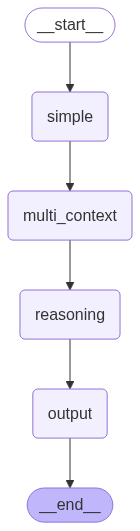

In [134]:
final_workflow

In [135]:
initial_state = {
    "docs": processed_docs[:4],
    "questions": [],
    "current_evolution": "simple",
    "messages": [],
    "done": False
}

final_state = await final_workflow.ainvoke(initial_state)

'simple state'
("doc: {'id': 'd9461fd6-6dfa-4be7-8d84-e4d32f2a0fba', 'content': 'number of "
 'excused absences that may be counted when determining whether a student '
 'completed the hours in a\\npayment period may not exceed the lesser '
 'of4\\nProgram 1: 30 semester hours and 36 weeks\\n1st payment period\\n12 '
 'semester hours\\nand 15 weeks\\n2nd payment period\\n12 semester hours\\nand '
 '15 weeks\\n3rd payment period\\n6 semester hours\\nand 6 weeks\\none '
 'academic year\\nremaining portion of program\\nThere is a single payment '
 'period for the remaining portion of the program, since at least one of the '
 "measures', 'metadata': {'producer': 'GPL Ghostscript 10.00.0', 'creator': "
 '\'wkhtmltopdf 0.12.6\', \'creationdate\': "D:20250418120630Z00\'00\'", '
 "'source': 'data/Academic_Calenders_Cost_of_Attendance_and_Packaging.pdf', "
 "'file_path': 'data/Academic_Calenders_Cost_of_Attendance_and_Packaging.pdf', "
 "'total_pages': 57, 'format': 'PDF 1.7', 'title': '', 'aut

In [136]:
pprint(final_state["output"])

{'answers': [{'answer': 'The lesser of 30 semester hours or 36 weeks.',
              'question': 'What is the maximum number of excused absences that '
                          "can be counted toward a student's hours in a "
                          'payment period, according to the key point?',
              'question_id': 'ad66f78a-6ed4-47a8-9024-5ffb8f7d69f2'},
             {'answer': 'The first and second periods are each 12 semester '
                        'hours over 15 weeks, and the third period is 6 '
                        'semester hours over 6 weeks.',
              'question': 'How are the three payment periods in Program 1 '
                          'structured in terms of semester hours and weeks?',
              'question_id': '26c38f4c-6b0a-4163-84a3-d6b1ae8d5010'},
             {'answer': 'The first and second payment periods each consist of '
                        '12 semester hours, and the third payment period '
                        'involves 6 semester